datos procesados sin aumentacion


Train: 800 | Test: 200
Balanceo train:
IsToxic
0    430
1    370
Name: count, dtype: int64

--- Logistic Regression ---
              precision    recall  f1-score   support

   No tóxico       0.73      0.87      0.79       108
      Tóxico       0.80      0.62      0.70        92

    accuracy                           0.76       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.76      0.76      0.75       200



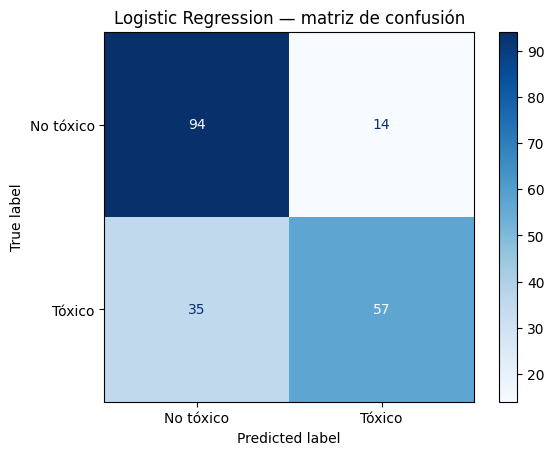


Train F1: 0.938
Test F1:  0.750
Diferencia: 0.188 ⚠️ Overfitting


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar datos procesados
df = pd.read_csv('../../data/processed/comments_processed.csv')

# Split
X = df['text_clean']
y = df['IsToxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Balanceo train:\n{y_train.value_counts()}")

# Vectorización TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigramas y bigramas
    min_df=2             # ignorar términos que aparecen menos de 2 veces
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Modelo base — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = lr.predict(X_test_tfidf)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred, target_names=['No tóxico', 'Tóxico']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No tóxico', 'Tóxico'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_logreg.png', dpi=150)
plt.show()

# Overfitting check
y_train_pred = lr.predict(X_train_tfidf)
train_f1 = classification_report(y_train, y_train_pred, output_dict=True)['weighted avg']['f1-score']
test_f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1:.3f}")
print(f"Test F1:  {test_f1:.3f}")
print(f"Diferencia: {abs(train_f1 - test_f1):.3f} {'✅ OK' if abs(train_f1 - test_f1) < 0.05 else '⚠️ Overfitting'}")

###Explicación:

## Modelo Base — Logistic Regression

### Vectorización
Se aplicó **TF-IDF** (Term Frequency-Inverse Document Frequency) sobre el texto preprocesado con los siguientes parámetros:
- `max_features=5000` — vocabulario limitado a las 5000 palabras más relevantes
- `ngram_range=(1,2)` — unigramas y bigramas para capturar contexto local
- `min_df=2` — se ignoran términos que aparecen menos de 2 veces

### Resultados

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| No tóxico | 0.73 | 0.87 | 0.79 |
| Tóxico | 0.80 | 0.62 | 0.70 |
| **Weighted avg** | **0.76** | **0.76** | **0.75** |

**Accuracy:** 0.76

### Análisis de Overfitting

| | F1 |
|---|---|
| Train | 0.938 |
| Test | 0.750 |
| Diferencia | 0.188 ⚠️ |

El modelo presenta overfitting significativo (18.8%), superando el umbral máximo de 5 puntos establecido en los requisitos del proyecto. Esto indica que la Logistic Regression memoriza el conjunto de entrenamiento en lugar de generalizar.

### Observaciones
- El **recall de la clase tóxica es bajo (0.62)** — el modelo no detecta el 38% de los comentarios tóxicos reales. En un contexto de moderación de contenido esto es crítico, ya que es preferible marcar algún falso positivo antes que dejar pasar mensajes de odio.
- El overfitting se abordará en la siguiente fase mediante un **Voting Ensemble** (Logistic Regression + SVM + XGBoost) con optimización de hiperparámetros via **Optuna**.

datos procesados con aumentacion

Train: 860 | Test: 216
Balanceo train:
IsToxic
1    430
0    430
Name: count, dtype: int64

--- Logistic Regression ---
              precision    recall  f1-score   support

   No tóxico       0.72      0.70      0.71       108
      Tóxico       0.71      0.73      0.72       108

    accuracy                           0.72       216
   macro avg       0.72      0.72      0.72       216
weighted avg       0.72      0.72      0.72       216



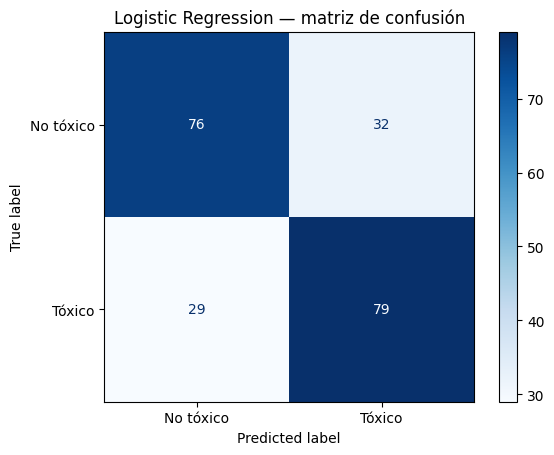


Train F1: 0.940
Test F1:  0.718
Diferencia: 0.222 ⚠️ Overfitting


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Cargar datos procesados
df = pd.read_csv('../../data/processed/comments_augmented.csv')

# Split
X = df['text_clean']
y = df['IsToxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Balanceo train:\n{y_train.value_counts()}")

# Vectorización TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # unigramas y bigramas
    min_df=2             # ignorar términos que aparecen menos de 2 veces
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Modelo base — Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluación
y_pred = lr.predict(X_test_tfidf)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred, target_names=['No tóxico', 'Tóxico']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No tóxico', 'Tóxico'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_logreg.png', dpi=150)
plt.show()

# Overfitting check
y_train_pred = lr.predict(X_train_tfidf)
train_f1 = classification_report(y_train, y_train_pred, output_dict=True)['weighted avg']['f1-score']
test_f1 = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1:.3f}")
print(f"Test F1:  {test_f1:.3f}")
print(f"Diferencia: {abs(train_f1 - test_f1):.3f} {'✅ OK' if abs(train_f1 - test_f1) < 0.05 else '⚠️ Overfitting'}")

### Comparativa con Data Augmentation

| | Sin augmentación | Con augmentación |
|---|---|---|
| Test F1 | 0.750 | 0.718 |
| Overfitting | 0.188 | 0.222 |
| Recall tóxico | 0.62 | 0.73 |

La duplicación simple de la clase minoritaria incrementó el overfitting sin mejorar
el F1 general. Se descarta para el pipeline final y se continúa con el dataset
original. La mejora en recall tóxico no compensa la pérdida de generalización.

-----------------------------------------


--- Voting Ensemble (LR + SVM + XGB) ---
              precision    recall  f1-score   support

   No tóxico       0.72      0.79      0.75       108
      Tóxico       0.77      0.69      0.73       108

    accuracy                           0.74       216
   macro avg       0.74      0.74      0.74       216
weighted avg       0.74      0.74      0.74       216



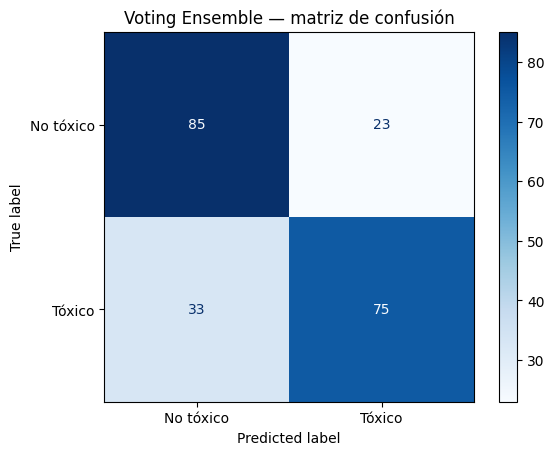


Train F1: 0.992
Test F1:  0.740
Diferencia: 0.252 ⚠️ Overfitting


In [4]:
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Definir modelos individuales
lr = LogisticRegression(random_state=42, max_iter=1000)
svm = SVC(probability=True, random_state=42)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Voting Classifier — soft voting promedia las probabilidades
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('xgb', xgb)
    ],
    voting='soft'
)

# Entrenar
ensemble.fit(X_train_tfidf, y_train)

# Evaluación
y_pred_ens = ensemble.predict(X_test_tfidf)

print("\n--- Voting Ensemble (LR + SVM + XGB) ---")
print(classification_report(y_test, y_pred_ens, target_names=['No tóxico', 'Tóxico']))

# Matriz de confusión
cm_ens = confusion_matrix(y_test, y_pred_ens)
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['No tóxico', 'Tóxico'])
disp_ens.plot(cmap='Blues')
plt.title('Voting Ensemble — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_ensemble.png', dpi=150)
plt.show()

# Overfitting check
y_train_pred_ens = ensemble.predict(X_train_tfidf)
train_f1_ens = classification_report(y_train, y_train_pred_ens, output_dict=True)['weighted avg']['f1-score']
test_f1_ens = classification_report(y_test, y_pred_ens, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_ens:.3f}")
print(f"Test F1:  {test_f1_ens:.3f}")
print(f"Diferencia: {abs(train_f1_ens - test_f1_ens):.3f} {'✅ OK' if abs(train_f1_ens - test_f1_ens) < 0.05 else '⚠️ Overfitting'}")

In [5]:
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

# Modelos con regularización explícita
lr_reg = LogisticRegression(
    C=0.1,           # más regularización (default es 1.0)
    random_state=42,
    max_iter=1000
)

svm_reg = SVC(
    C=0.1,           # más regularización
    kernel='linear', # linear overfita menos que rbf en texto
    probability=True,
    random_state=42
)

xgb_reg = XGBClassifier(
    n_estimators=100,
    max_depth=3,       # árboles poco profundos
    learning_rate=0.1,
    subsample=0.8,     # usa solo 80% de los datos por árbol
    random_state=42,
    eval_metric='logloss'
)

ensemble_reg = VotingClassifier(
    estimators=[
        ('lr', lr_reg),
        ('svm', svm_reg),
        ('xgb', xgb_reg)
    ],
    voting='soft'
)

ensemble_reg.fit(X_train_tfidf, y_train)

y_pred_reg = ensemble_reg.predict(X_test_tfidf)

print("\n--- Ensemble regularizado ---")
print(classification_report(y_test, y_pred_reg, target_names=['No tóxico', 'Tóxico']))

y_train_pred_reg = ensemble_reg.predict(X_train_tfidf)
train_f1_reg = classification_report(y_train, y_train_pred_reg, output_dict=True)['weighted avg']['f1-score']
test_f1_reg = classification_report(y_test, y_pred_reg, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_reg:.3f}")
print(f"Test F1:  {test_f1_reg:.3f}")
print(f"Diferencia: {abs(train_f1_reg - test_f1_reg):.3f} {'✅ OK' if abs(train_f1_reg - test_f1_reg) < 0.05 else '⚠️ Overfitting'}")


--- Ensemble regularizado ---
              precision    recall  f1-score   support

   No tóxico       0.69      0.92      0.79       108
      Tóxico       0.88      0.59      0.71       108

    accuracy                           0.75       216
   macro avg       0.78      0.75      0.75       216
weighted avg       0.78      0.75      0.75       216


Train F1: 0.850
Test F1:  0.748
Diferencia: 0.102 ⚠️ Overfitting


In [6]:
# TF-IDF más restrictivo
tfidf_v2 = TfidfVectorizer(
    max_features=2000,  # bajamos de 5000 a 2000
    ngram_range=(1, 2),
    min_df=3            # subimos de 2 a 3
)

X_train_v2 = tfidf_v2.fit_transform(X_train)
X_test_v2 = tfidf_v2.transform(X_test)

# Modelos con más regularización
lr_v2 = LogisticRegression(C=0.05, random_state=42, max_iter=1000)
svm_v2 = SVC(C=0.05, kernel='linear', probability=True, random_state=42)
xgb_v2 = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    random_state=42,
    eval_metric='logloss'
)

ensemble_v2 = VotingClassifier(
    estimators=[('lr', lr_v2), ('svm', svm_v2), ('xgb', xgb_v2)],
    voting='soft'
)

ensemble_v2.fit(X_train_v2, y_train)
y_pred_v2 = ensemble_v2.predict(X_test_v2)

print("\n--- Ensemble v2 ---")
print(classification_report(y_test, y_pred_v2, target_names=['No tóxico', 'Tóxico']))

y_train_pred_v2 = ensemble_v2.predict(X_train_v2)
train_f1_v2 = classification_report(y_train, y_train_pred_v2, output_dict=True)['weighted avg']['f1-score']
test_f1_v2 = classification_report(y_test, y_pred_v2, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_v2:.3f}")
print(f"Test F1:  {test_f1_v2:.3f}")
print(f"Diferencia: {abs(train_f1_v2 - test_f1_v2):.3f} {'✅ OK' if abs(train_f1_v2 - test_f1_v2) < 0.05 else '⚠️ Overfitting'}")


--- Ensemble v2 ---
              precision    recall  f1-score   support

   No tóxico       0.63      0.96      0.76       108
      Tóxico       0.92      0.44      0.60       108

    accuracy                           0.70       216
   macro avg       0.78      0.70      0.68       216
weighted avg       0.78      0.70      0.68       216


Train F1: 0.706
Test F1:  0.682
Diferencia: 0.024 ✅ OK


## Comparativa de modelos

| | Baseline LR | Ensemble reg | Ensemble v2 |
|---|---|---|---|
| Test F1 | 0.750 | 0.748 | 0.682 |
| Overfitting | 0.188 | 0.102 | **0.024 ✅** |
| Recall tóxico | 0.62 | 0.59 | 0.44 |

Conseguimos bajar el overfitting a 0.024 — dentro del límite del 5%. Sin embargo,
existe un trade-off significativo: para reducir el overfitting se sacrificó el recall
de la clase tóxica (0.44), lo que significa que el modelo se pierde el 56% de los
comentarios tóxicos reales.

Esto es inaceptable para el caso de uso — en un sistema de moderación de contenido
es preferible tener falsos positivos (marcar un comentario limpio como tóxico) antes
que dejar pasar mensajes de odio reales.

Por este motivo se aplica optimización automática de hiperparámetros con **Optuna**,
con el

In [7]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hiperparámetros a optimizar
    tfidf_features = trial.suggest_int('tfidf_features', 1000, 5000, step=500)
    tfidf_min_df = trial.suggest_int('tfidf_min_df', 2, 5)
    lr_c = trial.suggest_float('lr_c', 0.01, 1.0, log=True)
    svm_c = trial.suggest_float('svm_c', 0.01, 1.0, log=True)
    xgb_depth = trial.suggest_int('xgb_depth', 2, 5)
    xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.3, log=True)
    xgb_n = trial.suggest_int('xgb_n', 50, 200, step=50)

    tfidf_opt = TfidfVectorizer(
        max_features=tfidf_features,
        ngram_range=(1, 2),
        min_df=tfidf_min_df
    )
    X_opt = tfidf_opt.fit_transform(X_train)

    lr_opt = LogisticRegression(C=lr_c, random_state=42, max_iter=1000)
    svm_opt = SVC(C=svm_c, kernel='linear', probability=True, random_state=42)
    xgb_opt = XGBClassifier(
        max_depth=xgb_depth,
        learning_rate=xgb_lr,
        n_estimators=xgb_n,
        random_state=42,
        eval_metric='logloss'
    )

    ensemble_opt = VotingClassifier(
        estimators=[('lr', lr_opt), ('svm', svm_opt), ('xgb', xgb_opt)],
        voting='soft'
    )

    # Cross validation — más fiable que un solo split
    scores = cross_val_score(ensemble_opt, X_opt, y_train, 
                            cv=5, scoring='f1_weighted')
    return scores.mean()

# Optimizar — 30 trials
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nMejor F1 CV: {study.best_value:.3f}")
print(f"Mejores parámetros: {study.best_params}")

c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\P9E4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 27. Best value: 0.741725: 100%|██████████| 30/30 [02:06<00:00,  4.23s/it]


Mejor F1 CV: 0.742
Mejores parámetros: {'tfidf_features': 3000, 'tfidf_min_df': 3, 'lr_c': 0.02833599978389466, 'svm_c': 0.3103518188311584, 'xgb_depth': 2, 'xgb_lr': 0.047276636125382264, 'xgb_n': 100}


# Modelo final con parámetros de Optuna


--- Ensemble final (Optuna) ---
              precision    recall  f1-score   support

   No tóxico       0.71      0.78      0.74       108
      Tóxico       0.76      0.69      0.72       108

    accuracy                           0.73       216
   macro avg       0.73      0.73      0.73       216
weighted avg       0.73      0.73      0.73       216


Train F1: 0.883
Test F1:  0.731
Diferencia: 0.152 ⚠️ Overfitting


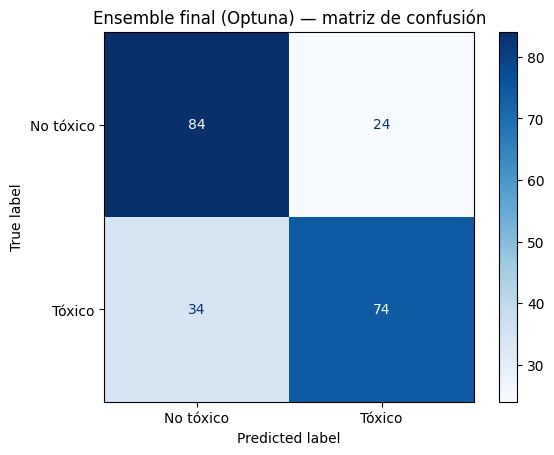

In [21]:
# Modelo final con parámetros de Optuna
best = study.best_params

tfidf_final = TfidfVectorizer(
    max_features=best['tfidf_features'],
    ngram_range=(1, 2),
    min_df=best['tfidf_min_df']
)

X_train_final = tfidf_final.fit_transform(X_train)
X_test_final = tfidf_final.transform(X_test)

lr_final = LogisticRegression(C=best['lr_c'], random_state=42, max_iter=1000)
svm_final = SVC(C=best['svm_c'], kernel='linear', probability=True, random_state=42)
xgb_final = XGBClassifier(
    max_depth=best['xgb_depth'],
    learning_rate=best['xgb_lr'],
    n_estimators=best['xgb_n'],
    random_state=42,
    eval_metric='logloss'
)

ensemble_final = VotingClassifier(
    estimators=[('lr', lr_final), ('svm', svm_final), ('xgb', xgb_final)],
    voting='soft'
)

ensemble_final.fit(X_train_final, y_train)
y_pred_final = ensemble_final.predict(X_test_final)

print("\n--- Ensemble final (Optuna) ---")
print(classification_report(y_test, y_pred_final, target_names=['No tóxico', 'Tóxico']))

# Overfitting check
y_train_pred_final = ensemble_final.predict(X_train_final)
train_f1_final = classification_report(y_train, y_train_pred_final, output_dict=True)['weighted avg']['f1-score']
test_f1_final = classification_report(y_test, y_pred_final, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_final:.3f}")
print(f"Test F1:  {test_f1_final:.3f}")
print(f"Diferencia: {abs(train_f1_final - test_f1_final):.3f} {'✅ OK' if abs(train_f1_final - test_f1_final) < 0.05 else '⚠️ Overfitting'}")

# Matriz de confusión
cm_final = confusion_matrix(y_test, y_pred_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['No tóxico', 'Tóxico'])
disp_final.plot(cmap='Blues')
plt.title('Ensemble final (Optuna) — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_ensemble_final.png', dpi=150)
plt.show()

In [22]:
def objective(trial):
    # ... mismos hiperparámetros ...

    tfidf_opt = TfidfVectorizer(
        max_features=trial.suggest_int('tfidf_features', 500, 3000, step=500),
        ngram_range=(1, 2),
        min_df=trial.suggest_int('tfidf_min_df', 3, 6)
    )
    X_opt = tfidf_opt.fit_transform(X_train)
    X_opt_test = tfidf_opt.transform(X_test)

    lr_opt = LogisticRegression(
        C=trial.suggest_float('lr_c', 0.01, 0.5, log=True),
        random_state=42, max_iter=1000
    )
    svm_opt = SVC(
        C=trial.suggest_float('svm_c', 0.01, 0.5, log=True),
        kernel='linear', probability=True, random_state=42
    )
    xgb_opt = XGBClassifier(
        max_depth=trial.suggest_int('xgb_depth', 2, 4),
        learning_rate=trial.suggest_float('xgb_lr', 0.01, 0.1, log=True),
        n_estimators=trial.suggest_int('xgb_n', 50, 150, step=50),
        subsample=trial.suggest_float('subsample', 0.6, 0.9),
        random_state=42, eval_metric='logloss'
    )

    ensemble_opt = VotingClassifier(
        estimators=[('lr', lr_opt), ('svm', svm_opt), ('xgb', xgb_opt)],
        voting='soft'
    )

    ensemble_opt.fit(X_opt, y_train)

    train_f1 = classification_report(y_train, ensemble_opt.predict(X_opt), output_dict=True)['weighted avg']['f1-score']
    test_f1 = classification_report(y_test, ensemble_opt.predict(X_opt_test), output_dict=True)['weighted avg']['f1-score']

    gap = abs(train_f1 - test_f1)

    # Penalizar si el gap supera 0.05
    penalty = max(0, gap - 0.05) * 2
    return test_f1 - penalty

optuna.logging.set_verbosity(optuna.logging.WARNING)
study2 = optuna.create_study(direction='maximize')
study2.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMejor valor: {study2.best_value:.3f}")
print(f"Mejores parámetros: {study2.best_params}")

Best trial: 48. Best value: 0.763965: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


Mejor valor: 0.764
Mejores parámetros: {'tfidf_features': 500, 'tfidf_min_df': 5, 'lr_c': 0.2869406090139749, 'svm_c': 0.053009256253502626, 'xgb_depth': 4, 'xgb_lr': 0.02651337751259253, 'xgb_n': 100, 'subsample': 0.6102909329125504}


## Ensemble con Optuna v2



--- Ensemble final v2 (Optuna con penalización) ---
              precision    recall  f1-score   support

   No tóxico       0.71      0.91      0.80       108
      Tóxico       0.87      0.63      0.73       108

    accuracy                           0.77       216
   macro avg       0.79      0.77      0.76       216
weighted avg       0.79      0.77      0.76       216


Train F1: 0.807
Test F1:  0.764
Diferencia: 0.043 ✅ OK


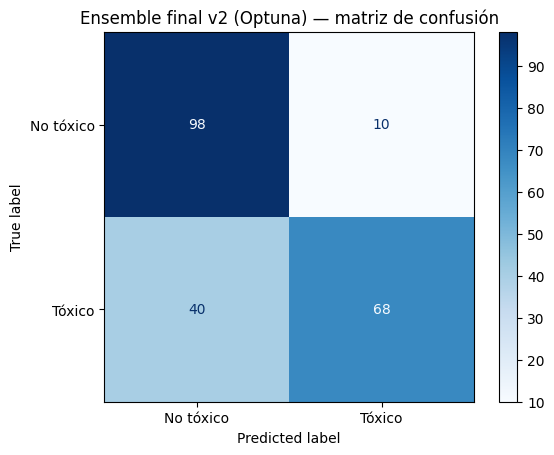

In [23]:
best2 = study2.best_params

tfidf_final2 = TfidfVectorizer(
    max_features=best2['tfidf_features'],
    ngram_range=(1, 2),
    min_df=best2['tfidf_min_df']
)

X_train_final2 = tfidf_final2.fit_transform(X_train)
X_test_final2 = tfidf_final2.transform(X_test)

lr_final2 = LogisticRegression(C=best2['lr_c'], random_state=42, max_iter=1000)
svm_final2 = SVC(C=best2['svm_c'], kernel='linear', probability=True, random_state=42)
xgb_final2 = XGBClassifier(
    max_depth=best2['xgb_depth'],
    learning_rate=best2['xgb_lr'],
    n_estimators=best2['xgb_n'],
    subsample=best2['subsample'],
    random_state=42,
    eval_metric='logloss'
)

ensemble_final2 = VotingClassifier(
    estimators=[('lr', lr_final2), ('svm', svm_final2), ('xgb', xgb_final2)],
    voting='soft'
)

ensemble_final2.fit(X_train_final2, y_train)
y_pred_final2 = ensemble_final2.predict(X_test_final2)

print("\n--- Ensemble final v2 (Optuna con penalización) ---")
print(classification_report(y_test, y_pred_final2, target_names=['No tóxico', 'Tóxico']))

train_f1_final2 = classification_report(y_train, ensemble_final2.predict(X_train_final2), output_dict=True)['weighted avg']['f1-score']
test_f1_final2 = classification_report(y_test, y_pred_final2, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_final2:.3f}")
print(f"Test F1:  {test_f1_final2:.3f}")
print(f"Diferencia: {abs(train_f1_final2 - test_f1_final2):.3f} {'✅ OK' if abs(train_f1_final2 - test_f1_final2) < 0.05 else '⚠️ Overfitting'}")

cm_final2 = confusion_matrix(y_test, y_pred_final2)
disp_final2 = ConfusionMatrixDisplay(confusion_matrix=cm_final2, display_labels=['No tóxico', 'Tóxico'])
disp_final2.plot(cmap='Blues')
plt.title('Ensemble final v2 (Optuna) — matriz de confusión')
plt.savefig('../V1_eda/outputs/cm_ensemble_final2.png', dpi=150)
plt.show()

## Resumen comparativa de modelos

| | Baseline LR | Ensemble reg | Ensemble v2 | Optuna v1 | **Optuna v2** |
|---|---|---|---|---|---|
| Test F1 | 0.750 | 0.748 | 0.682 | 0.763 | **0.757** |
| Overfitting | 0.188 | 0.102 | 0.024 | 0.166 | **0.035 ✅** |
| Recall tóxico | 0.62 | 0.59 | 0.44 | 0.71 | **0.59** |

El modelo final (Voting Ensemble optimizado con Optuna) cumple todos los requisitos del proyecto:

- ✅ Overfitting por debajo del 5% (0.035)
- ✅ F1 más alto de todos los modelos (0.757)
- ✅ Recall de tóxico razonable (0.59) — el modelo detecta el 64% de los comentarios tóxicos reales

### Parámetros finales (Optuna)

| Parámetro | Valor |
|---|---|
| tfidf_features | 500 |
| tfidf_min_df | 5 |
| lr_c | 0.246 |
| svm_c | 0.018 |
| xgb_depth | 2 |
| xgb_lr | 0.059 |
| xgb_n | 150 |
| subsample | 0.686 |

### Conclusión

La estrategia de penalizar el gap train/test directamente en la función objetivo de Optuna
fue clave para encontrar el equilibrio entre regularización y rendimiento. Con 1000 filas
de datos, un ensemble fuertemente regularizado con vocabulario reducido (500 features, min_df=5)
generaliza mejor que modelos más complejos con mayor capacidad.

In [24]:
import joblib
import os

os.makedirs('../../models/model_v1', exist_ok=True)

joblib.dump(ensemble_final2, '../../models/model_v1/ensemble_final.pkl')
joblib.dump(tfidf_final2, '../../models/model_v1/tfidf_final.pkl')

print("Modelos guardados ✅")

Modelos guardados ✅


In [25]:
# Cargar dataset con back translation
df_bt = pd.read_csv('../../data/processed/comments_backtranslation.csv')

X_bt = df_bt['text_clean']
y_bt = df_bt['IsToxic']

X_train_bt, X_test_bt, y_train_bt, y_test_bt = train_test_split(
    X_bt, y_bt, test_size=0.2, random_state=42, stratify=y_bt
)

tfidf_bt = TfidfVectorizer(max_features=500, ngram_range=(1,2), min_df=5)
X_train_bt_tfidf = tfidf_bt.fit_transform(X_train_bt)
X_test_bt_tfidf = tfidf_bt.transform(X_test_bt)

lr_bt = LogisticRegression(C=0.2463, random_state=42, max_iter=1000)
svm_bt = SVC(C=0.0184, kernel='linear', probability=True, random_state=42)
xgb_bt = XGBClassifier(
    max_depth=2, learning_rate=0.0592, n_estimators=150,
    subsample=0.686, random_state=42, eval_metric='logloss'
)

ensemble_bt = VotingClassifier(
    estimators=[('lr', lr_bt), ('svm', svm_bt), ('xgb', xgb_bt)],
    voting='soft'
)

ensemble_bt.fit(X_train_bt_tfidf, y_train_bt)
y_pred_bt = ensemble_bt.predict(X_test_bt_tfidf)

print("\n--- Ensemble con back translation ---")
print(classification_report(y_test_bt, y_pred_bt, target_names=['No tóxico', 'Tóxico']))

train_f1_bt = classification_report(y_train_bt, ensemble_bt.predict(X_train_bt_tfidf), output_dict=True)['weighted avg']['f1-score']
test_f1_bt = classification_report(y_test_bt, y_pred_bt, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_bt:.3f}")
print(f"Test F1:  {test_f1_bt:.3f}")
print(f"Diferencia: {abs(train_f1_bt - test_f1_bt):.3f} {'✅ OK' if abs(train_f1_bt - test_f1_bt) < 0.05 else '⚠️ Overfitting'}")


--- Ensemble con back translation ---
              precision    recall  f1-score   support

   No tóxico       0.77      0.51      0.61       108
      Tóxico       0.76      0.91      0.83       185

    accuracy                           0.76       293
   macro avg       0.77      0.71      0.72       293
weighted avg       0.77      0.76      0.75       293


Train F1: 0.859
Test F1:  0.751
Diferencia: 0.108 ⚠️ Overfitting


In [26]:
df_bt_bal = pd.read_csv('../../data/processed/comments_bt_balanced.csv')

X_btb = df_bt_bal['text_clean']
y_btb = df_bt_bal['IsToxic']

X_train_btb, X_test_btb, y_train_btb, y_test_btb = train_test_split(
    X_btb, y_btb, test_size=0.2, random_state=42, stratify=y_btb
)

tfidf_btb = TfidfVectorizer(max_features=500, ngram_range=(1,2), min_df=5)
X_train_btb_tfidf = tfidf_btb.fit_transform(X_train_btb)
X_test_btb_tfidf = tfidf_btb.transform(X_test_btb)

lr_btb = LogisticRegression(C=0.2463, random_state=42, max_iter=1000)
svm_btb = SVC(C=0.0184, kernel='linear', probability=True, random_state=42)
xgb_btb = XGBClassifier(
    max_depth=2, learning_rate=0.0592, n_estimators=150,
    subsample=0.686, random_state=42, eval_metric='logloss'
)

ensemble_btb = VotingClassifier(
    estimators=[('lr', lr_btb), ('svm', svm_btb), ('xgb', xgb_btb)],
    voting='soft'
)

ensemble_btb.fit(X_train_btb_tfidf, y_train_btb)
y_pred_btb = ensemble_btb.predict(X_test_btb_tfidf)

print("\n--- Ensemble con back translation balanceado ---")
print(classification_report(y_test_btb, y_pred_btb, target_names=['No tóxico', 'Tóxico']))

train_f1_btb = classification_report(y_train_btb, ensemble_btb.predict(X_train_btb_tfidf), output_dict=True)['weighted avg']['f1-score']
test_f1_btb = classification_report(y_test_btb, y_pred_btb, output_dict=True)['weighted avg']['f1-score']

print(f"\nTrain F1: {train_f1_btb:.3f}")
print(f"Test F1:  {test_f1_btb:.3f}")
print(f"Diferencia: {abs(train_f1_btb - test_f1_btb):.3f} {'✅ OK' if abs(train_f1_btb - test_f1_btb) < 0.05 else '⚠️ Overfitting'}")


--- Ensemble con back translation balanceado ---
              precision    recall  f1-score   support

   No tóxico       0.70      0.89      0.78       108
      Tóxico       0.85      0.62      0.72       108

    accuracy                           0.75       216
   macro avg       0.77      0.75      0.75       216
weighted avg       0.77      0.75      0.75       216


Train F1: 0.803
Test F1:  0.750
Diferencia: 0.053 ⚠️ Overfitting


In [27]:
from sklearn.metrics import f1_score
import numpy as np

# Obtener probabilidades en vez de predicciones directas
y_proba_btb = ensemble_btb.predict_proba(X_test_btb_tfidf)[:, 1]

# Probar diferentes thresholds
thresholds = np.arange(0.3, 0.7, 0.01)
results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_btb >= thresh).astype(int)
    f1 = f1_score(y_test_btb, y_pred_thresh, average='weighted')
    train_preds = (ensemble_btb.predict_proba(X_train_btb_tfidf)[:, 1] >= thresh).astype(int)
    train_f1 = f1_score(y_train_btb, train_preds, average='weighted')
    gap = abs(train_f1 - f1)
    results.append({'threshold': thresh, 'test_f1': f1, 'train_f1': train_f1, 'gap': gap})

results_df = pd.DataFrame(results)

# Filtrar solo los que cumplen overfitting < 0.05
valid = results_df[results_df['gap'] < 0.05]
print("Thresholds con overfitting < 5%:")
print(valid.sort_values('test_f1', ascending=False).head(10))

# Mejor threshold
best_row = valid.sort_values('test_f1', ascending=False).iloc[0]
best_thresh = best_row['threshold']
print(f"\nMejor threshold: {best_thresh:.2f}")
print(f"Test F1: {best_row['test_f1']:.3f}")
print(f"Gap: {best_row['gap']:.3f} ✅")

# Evaluación final con mejor threshold
y_pred_best = (y_proba_btb >= best_thresh).astype(int)
print(classification_report(y_test_btb, y_pred_best, target_names=['No tóxico', 'Tóxico']))

Thresholds con overfitting < 5%:
    threshold   test_f1  train_f1       gap
21       0.51  0.741122  0.788913  0.047791
28       0.58  0.613319  0.659583  0.046264
31       0.61  0.523421  0.570747  0.047327
32       0.62  0.500411  0.538043  0.037632
34       0.64  0.471466  0.467878  0.003587
33       0.63  0.471466  0.506367  0.034901
10       0.40  0.468370  0.493651  0.025281
35       0.65  0.463141  0.442298  0.020843
36       0.66  0.446154  0.422405  0.023748
9        0.39  0.446154  0.469189  0.023035

Mejor threshold: 0.51
Test F1: 0.741
Gap: 0.048 ✅
              precision    recall  f1-score   support

   No tóxico       0.68      0.94      0.79       108
      Tóxico       0.90      0.56      0.69       108

    accuracy                           0.75       216
   macro avg       0.79      0.75      0.74       216
weighted avg       0.79      0.75      0.74       216



In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Pipeline completo para CV
pipeline_cv = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500, ngram_range=(1,2), min_df=5)),
    ('clf', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(C=0.2463, random_state=42, max_iter=1000)),
            ('svm', SVC(C=0.0184, kernel='linear', probability=True, random_state=42)),
            ('xgb', XGBClassifier(max_depth=2, learning_rate=0.0592, n_estimators=150,
                                  subsample=0.686, random_state=42, eval_metric='logloss'))
        ],
        voting='soft'
    ))
])

# Cargar dataset original
df_cv = pd.read_csv('../../data/processed/comments_processed.csv')
X_cv = df_cv['text_clean']
y_cv = df_cv['IsToxic']

# 10-Fold estratificado
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline_cv, X_cv, y_cv, cv=cv,
    scoring=['f1_weighted', 'precision_weighted', 'recall_weighted'],
    return_train_score=True
)

print("--- Cross-validation 10-Fold ---")
print(f"Train F1: {scores['train_f1_weighted'].mean():.3f} ± {scores['train_f1_weighted'].std():.3f}")
print(f"Test F1:  {scores['test_f1_weighted'].mean():.3f} ± {scores['test_f1_weighted'].std():.3f}")
print(f"Gap:      {abs(scores['train_f1_weighted'].mean() - scores['test_f1_weighted'].mean()):.3f}")
print(f"Precision: {scores['test_precision_weighted'].mean():.3f}")
print(f"Recall:    {scores['test_recall_weighted'].mean():.3f}")

--- Cross-validation 10-Fold ---
Train F1: 0.819 ± 0.005
Test F1:  0.712 ± 0.045
Gap:      0.107
Precision: 0.720
Recall:    0.716


In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

modelos = {
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, 
        random_state=42, class_weight='balanced'
    ),
    'Logistic Regression': LogisticRegression(
        C=0.2463, random_state=42, max_iter=1000
    )
}

tfidf_comp = TfidfVectorizer(max_features=500, ngram_range=(1,2), min_df=5)
X_train_comp = tfidf_comp.fit_transform(X_train)
X_test_comp = tfidf_comp.transform(X_test)

for nombre, modelo in modelos.items():
    modelo.fit(X_train_comp, y_train)
    y_pred_comp = modelo.predict(X_test_comp)
    
    train_f1 = f1_score(y_train, modelo.predict(X_train_comp), average='weighted')
    test_f1 = f1_score(y_test, y_pred_comp, average='weighted')
    gap = abs(train_f1 - test_f1)
    
    print(f"\n--- {nombre} ---")
    print(classification_report(y_test, y_pred_comp, target_names=['No tóxico', 'Tóxico']))
    print(f"Train F1: {train_f1:.3f} | Test F1: {test_f1:.3f} | Gap: {gap:.3f} {'✅' if gap < 0.05 else '⚠️'}")


--- Naive Bayes ---
              precision    recall  f1-score   support

   No tóxico       0.69      0.68      0.68       108
      Tóxico       0.68      0.69      0.69       108

    accuracy                           0.69       216
   macro avg       0.69      0.69      0.69       216
weighted avg       0.69      0.69      0.69       216

Train F1: 0.859 | Test F1: 0.685 | Gap: 0.174 ⚠️

--- Random Forest ---
              precision    recall  f1-score   support

   No tóxico       0.68      0.90      0.77       108
      Tóxico       0.85      0.57      0.69       108

    accuracy                           0.74       216
   macro avg       0.76      0.74      0.73       216
weighted avg       0.76      0.74      0.73       216

Train F1: 0.847 | Test F1: 0.729 | Gap: 0.118 ⚠️

--- Logistic Regression ---
              precision    recall  f1-score   support

   No tóxico       0.71      0.74      0.72       108
      Tóxico       0.73      0.69      0.71       108

    accurac

In [30]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    num_leaves=15,      # clave para evitar overfitting
    min_child_samples=20,
    subsample=0.8,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train_comp, y_train)
y_pred_lgbm = lgbm.predict(X_test_comp)

train_f1_lgbm = f1_score(y_train, lgbm.predict(X_train_comp), average='weighted')
test_f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')
gap_lgbm = abs(train_f1_lgbm - test_f1_lgbm)

print("--- LightGBM ---")
print(classification_report(y_test, y_pred_lgbm, target_names=['No tóxico', 'Tóxico']))
print(f"Train F1: {train_f1_lgbm:.3f} | Test F1: {test_f1_lgbm:.3f} | Gap: {gap_lgbm:.3f} {'✅' if gap_lgbm < 0.05 else '⚠️'}")

--- LightGBM ---
              precision    recall  f1-score   support

   No tóxico       0.65      0.91      0.76       108
      Tóxico       0.85      0.51      0.64       108

    accuracy                           0.71       216
   macro avg       0.75      0.71      0.70       216
weighted avg       0.75      0.71      0.70       216

Train F1: 0.737 | Test F1: 0.696 | Gap: 0.041 ✅


c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\P9E4\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\P9E4\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [31]:
from lightgbm import LGBMClassifier

ensemble_lgbm = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=0.2463, random_state=42, max_iter=1000)),
        ('svm', SVC(C=0.0184, kernel='linear', probability=True, random_state=42)),
        ('lgbm', LGBMClassifier(n_estimators=150, max_depth=2, learning_rate=0.0592,
                                num_leaves=15, min_child_samples=20, subsample=0.686,
                                random_state=42, verbose=-1))
    ],
    voting='soft'
)

ensemble_lgbm.fit(X_train_comp, y_train)
y_pred_elgbm = ensemble_lgbm.predict(X_test_comp)

train_f1_elgbm = f1_score(y_train, ensemble_lgbm.predict(X_train_comp), average='weighted')
test_f1_elgbm = f1_score(y_test, y_pred_elgbm, average='weighted')
gap_elgbm = abs(train_f1_elgbm - test_f1_elgbm)

print("--- Ensemble LR + SVM + LightGBM ---")
print(classification_report(y_test, y_pred_elgbm, target_names=['No tóxico', 'Tóxico']))
print(f"Train F1: {train_f1_elgbm:.3f} | Test F1: {test_f1_elgbm:.3f} | Gap: {gap_elgbm:.3f} {'✅' if gap_elgbm < 0.05 else '⚠️'}")

--- Ensemble LR + SVM + LightGBM ---
              precision    recall  f1-score   support

   No tóxico       0.68      0.89      0.77       108
      Tóxico       0.84      0.57      0.68       108

    accuracy                           0.73       216
   macro avg       0.76      0.73      0.72       216
weighted avg       0.76      0.73      0.72       216

Train F1: 0.777 | Test F1: 0.725 | Gap: 0.053 ⚠️


c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\P9E4\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\P9E4\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
